# নেভ বায়েস (Naive Bayes)**গল্প: সম্ভাবনা দিয়ে分類**কল্পনা করো তুমি একটি ঝুড়িতে আপেল আর কমলা মিশিয়ে রেখেছ। তুমি একটি ফল তুলে দেখো এটি গোলাকার আর কমলা রঙের। তাহলে এটি কী হওয়ার সম্ভাবনা বেশি? কমলা!নেভ বায়েস প্রতিটি feature-এর সম্ভাবনা আলাদাভাবে দেখে এবং সব সম্ভাবনা একত্রিত করে সিদ্ধান্ত নেয়। এটিকে 'naive' (সরল) বলা হয় কারণ এটি মনে করে সব feature একে অপরের থেকে স্বাধীন - যা বাস্তবে সবসময় সত্য নয়!

## আমরা কী শিখব?1. GaussianNB (সংখ্যাসূচক ডেটার জন্য)2. MultinomialNB (গণনার ডেটার জন্য)3. Iris ডেটাসেটে ক্লাসিফিকেশন4. Probability আউটপুট দেখা

## প্রথমে লাইব্রেরি ইম্পোর্ট করি

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
print('লাইব্রেরি ইম্পোর্ট সফল হয়েছে!')

লাইব্রেরি ইম্পোর্ট সফল হয়েছে!


## Iris ডেটাসেট লোড করিIris ডেটাসেটে 3 প্রজাতির ফুল আছে। GaussianNB দিয়ে ক্লাসিফিকেশন করি।

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)
print('ট্রেন সেট:', X_train.shape[0], 'নমুনা')
print('টেস্ট সেট:', X_test.shape[0], 'নমুনা')

ট্রেন সেট: 112 নমুনা
টেস্ট সেট: 38 নমুনা


## GaussianNB মডেল তৈরিGaussianNB ধরে নেয় প্রতিটি feature একটি Gaussian (Normal) distribution অনুসরণ করে।

In [3]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
print('ট্রেন accuracy:', gnb.score(X_train, y_train))
print('টেস্ট accuracy:', gnb.score(X_test, y_test))

ট্রেন accuracy: 0.9464285714285714
টেস্ট accuracy: 1.0


## Probability আউটপুট দেখাGaussianNB-এর সবচেয়ে মজার বৈশিষ্ট্য হলো এটি প্রতিটি ক্লাসের জন্য probability দেয়! predict_proba দিয়ে দেখা যাক।

In [4]:
probs = gnb.predict_proba(X_test)
print('প্রথম 5 টেস্ট নমুনার probability:')
print(probs[:5])
print()
print('ক্লাসের নাম:', iris.target_names)
print()
for i in range(5):
    pred_class = np.argmax(probs[i])
    confidence = probs[i][pred_class]
    true_class = y_test[i]
    print('নমুনা {}: প্রেডিক্ট {}, actual {}, confidence {:.3f}'.format(
        i, iris.target_names[pred_class],
        iris.target_names[true_class], confidence))

প্রথম 5 টেস্ট নমুনার probability:
[[1.34178204e-094 9.95499546e-001 4.50045385e-003]
 [1.00000000e+000 1.45352081e-013 1.02352166e-020]
 [1.40591061e-302 6.04667827e-012 1.00000000e+000]
 [1.94544549e-097 9.76485329e-001 2.35146713e-002]
 [1.46082354e-110 8.51147229e-001 1.48852771e-001]]

ক্লাসের নাম: ['setosa' 'versicolor' 'virginica']

নমুনা 0: প্রেডিক্ট versicolor, actual versicolor, confidence 0.995
নমুনা 1: প্রেডিক্ট setosa, actual setosa, confidence 1.000
নমুনা 2: প্রেডিক্ট virginica, actual virginica, confidence 1.000
নমুনা 3: প্রেডিক্ট versicolor, actual versicolor, confidence 0.976
নমুনা 4: প্রেডিক্ট versicolor, actual versicolor, confidence 0.851


## MultinomialNBMultinomialNB টেক্সট বা গণনার ডেটার জন্য ভালো (যেমন শব্দ গণনা)। এখানে আমরা make_classification দিয়ে ডেটা তৈরি করে试试 করি।

In [5]:
X_mn, y_mn = make_classification(n_samples=100, n_features=5,
                                 n_informative=3, random_state=42)
X_mn = np.abs(X_mn).astype(int)
Xmn_train, Xmn_test, ymn_train, ymn_test = train_test_split(
    X_mn, y_mn, random_state=42)
mnb = MultinomialNB()
mnb.fit(Xmn_train, ymn_train)
print('MultinomialNB accuracy:', mnb.score(Xmn_test, ymn_test))

MultinomialNB accuracy: 0.56


## GaussianNB vs MultinomialNB তুলনাদুটো মডেল Iris ডেটাসেটে কেমন কাজ করে দেখি।

In [6]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
print('GaussianNB accuracy:', gnb.score(X_test, y_test))
try:
    mnb = MultinomialNB()
    mnb.fit(X_train, y_train)
    print('MultinomialNB accuracy:', mnb.score(X_test, y_test))
except Exception as e:
    print('MultinomialNB error (negative values):', e)

GaussianNB accuracy: 1.0
MultinomialNB accuracy: 0.9736842105263158


## Probability-র ভিজুয়ালাইজেশননিচে প্রতিটি টেস্ট নমুনার জন্য ক্লাস probability-র বার চার্ট দেখি।

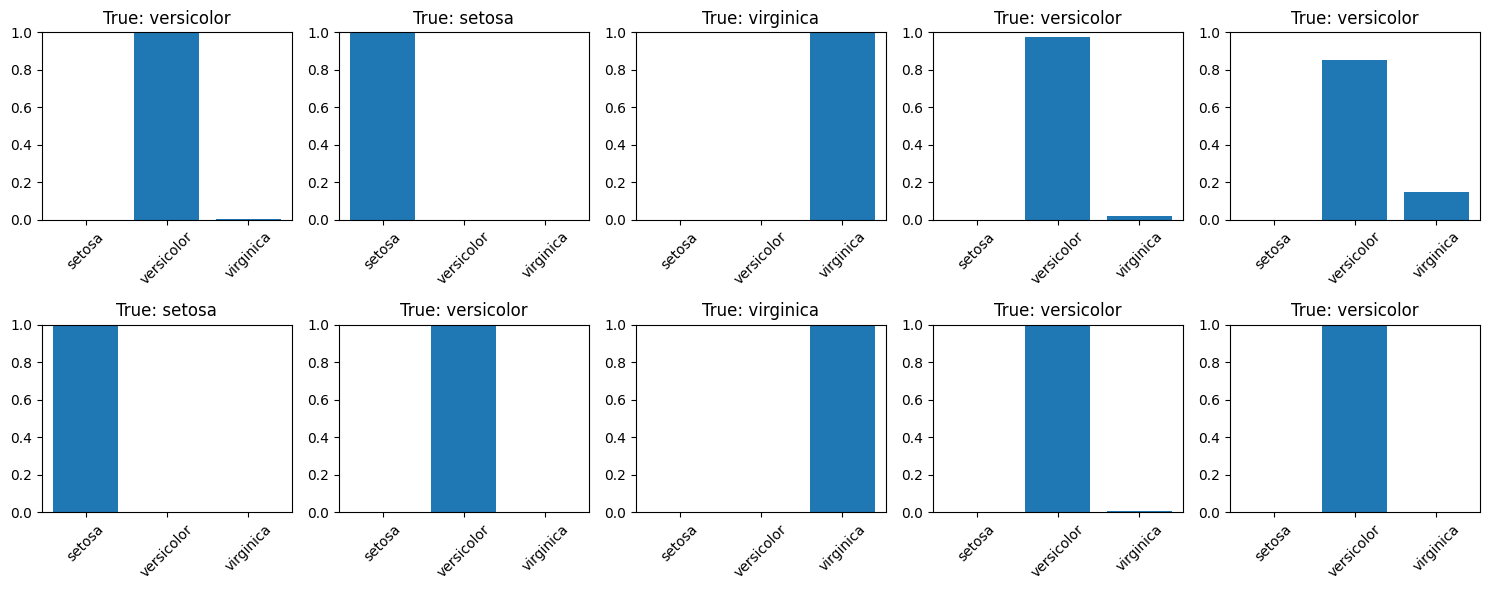

In [7]:
probs_all = gnb.predict_proba(X_test)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].bar(range(3), probs_all[i])
    axes[i].set_title('True: {}'.format(iris.target_names[y_test[i]]))
    axes[i].set_xticks(range(3))
    axes[i].set_xticklabels(iris.target_names, rotation=45)
    axes[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## সারসংক্ষেপ| মডেল | ডেটার ধরন | উদাহরণ |
|-------|-----------|--------|
| GaussianNB | ধারাবাহিক সংখ্যা (continuous) | Iris features |
| MultinomialNB | গণনার সংখ্যা (counts) | শব্দ গণনা, TF-IDF |
নেভ বায়েস খুব দ্রুত, ছোট ডেটার জন্য ভালো, এবং probability আউটপুট দেয়!